In [1]:
import pandas as pd
import numpy as np
import pyarrow.parquet as pq

import os
import matplotlib.pyplot as plt
import json
# from coffea.nanoevents import NanoEventsFactory, BaseSchema
# import uproot
import awkward as ak
import hist
# from plotting import * 
from tqdm import tqdm
# from agc_schema import AGCSchema

import mplhep as hep
plt.style.use([hep.style.CMS])

In [3]:
pmap = {}

pmap['QCD'] = [
    'QCD_HT-100to200', 'QCD_HT-200to400', 'QCD_HT-400to600', 
    'QCD_HT-600to800', 'QCD_HT-800to1000', 'QCD_HT-1000to1200', 
    'QCD_HT-1200to1500', 'QCD_HT-1500to2000', 'QCD_HT-2000'
    ]

pmap['Zjets_had_1j'] = [
    'Zto2Q-2Jets_PTQQ-100to200_1J', 'Zto2Q-2Jets_PTQQ-200to400_1J',
    'Zto2Q-2Jets_PTQQ-400to600_1J', 'Zto2Q-2Jets_PTQQ-600_1J'
    ]

pmap['Zjets_had_2j'] = [
    'Zto2Q-2Jets_PTQQ-100to200_2J', 'Zto2Q-2Jets_PTQQ-200to400_2J',
    'Zto2Q-2Jets_PTQQ-400to600_2J', 'Zto2Q-2Jets_PTQQ-600_2J'
    ]

pmap['Wjets_had_1j'] = [
    'Zto2Q-2Jets_PTQQ-100to200_1J', 'Zto2Q-2Jets_PTQQ-200to400_1J',
    'Zto2Q-2Jets_PTQQ-400to600_1J', 'Zto2Q-2Jets_PTQQ-600_1J'
    ]

pmap['Wjets_had_2j'] = [
    'Wto2Q-2Jets_PTQQ-100to200_2J', 'Wto2Q-2Jets_PTQQ-200to400_2J',
    'Wto2Q-2Jets_PTQQ-400to600_2J', 'Wto2Q-2Jets_PTQQ-600_2J'
    ]

pmap['Hbb_all'] = [
    'ggZH_Hto2B_Zto2L_M-125', 'ggZH_Hto2B_Zto2Nu_M-125', 'ggZH_Hto2B_Zto2Q_M-125',
    'GluGluHto2B_M-125', 'ttHto2B_M-125', 'VBFHto2B_M-125',
    'WminusH_Hto2B_Wto2Q_M-125', 'WminusH_Hto2B_WtoLNu_M-125', 
    'WplusH_Hto2B_Wto2Q_M-125', 'WplusH_Hto2B_WtoLNu_M-125',
    'ZH_Hto2B_Zto2L_M-125', 'ZH_Hto2B_Zto2Nu_M-125', 'ZH_Hto2B_Zto2Q_M-125'
    ]

pmap['VV'] = ['WW', 'WZ', 'ZZ']

pmap['ggF'] = ['GluGluHto2B_M-125']

pmap['VBF'] = ['VBFHto2B_M-125']

pmap['WH'] = ['WminusH_Hto2B_Wto2Q_M-125', 'WplusH_Hto2B_Wto2Q_M-125',
              'WminusH_Hto2B_WtoLNu_M-125', 'WplusH_Hto2B_WtoLNu_M-125']

pmap['ZH'] = ['ZH_Hto2B_Zto2Q_M-125', 'ZH_Hto2B_Zto2L_M-125', 'ZH_Hto2B_Zto2Nu_M-125',
              'ggZH_Hto2B_Zto2Q_M-125', 'ggZH_Hto2B_Zto2L_M-125', 'ggZH_Hto2B_Zto2Nu_M-125']

pmap['VH'] = pmap['WH']+pmap['ZH']

pmap['ttH'] = ['ttHto2B_M-125']

pmap['ttbar'] = ['TTto4Q', 'TTto2L2Nu', 'TTtoLNu2Q']

pmap['Jet_data'] = ['JetMET_Run2023Cv1', 'JetMET_Run2023Cv2', 
                    'JetMET_Run2023Cv3', 'JetMET_Run2023Cv4',]

pmap['background'] = pmap['QCD']+pmap['Wjets_had_2j']+pmap['Wjets_had_1j'] +pmap['Zjets_had_1j']+pmap['VV']+pmap['ttbar']

print(pmap['VH'])

pmap_file = './samples.json'

with open(pmap_file, 'w') as json_file:
    json.dump(pmap, json_file)

['WminusH_Hto2B_Wto2Q_M-125', 'WplusH_Hto2B_Wto2Q_M-125', 'WminusH_Hto2B_WtoLNu_M-125', 'WplusH_Hto2B_WtoLNu_M-125', 'ZH_Hto2B_Zto2Q_M-125', 'ZH_Hto2B_Zto2L_M-125', 'ZH_Hto2B_Zto2Nu_M-125', 'ggZH_Hto2B_Zto2Q_M-125', 'ggZH_Hto2B_Zto2L_M-125', 'ggZH_Hto2B_Zto2Nu_M-125']


In [10]:
def minjetkin(df):
    # fatjets = df['ak8FatJetmsoftdrop', 'ak8FatJetPt', 'ak8FatJetEta']
    # print(df['ak8FatJetmsoftdrop'].shape)
    fatjet_msd = df['ak8FatJetmsoftdrop'].values[:,0]
    fatjet_pt = df['ak8FatJetPt'].values[:,0]
    fatjet_eta = df['ak8FatJetEta'].values[:,0]
        # fatjets['msdcorr'] = fatjets.msoftdrop
        # fatjets['qcdrho'] = 2 * np.log(fatjets.msdcorr / fatjets.pt)
    candidatejet = df[
            (fatjet_pt > 200)
            & (abs(fatjet_eta) < 2.5)
            # & fatjets.isTight 
        ]

    # candidatejet = candidatejet[:, :2]
    # candidatejet = ak.firsts(candidatejet[ak.argmax(candidatejet.particleNet_XbbVsQCD, axis=1, keepdims=True)])

    # bvl = candidatejet.particleNet_XbbVsQCD
    minjetkin=np.array([
            (candidatejet['ak8FatJetPt'] >= 450)
            & (candidatejet['ak8FatJetPt']< 1200)
            & (candidatejet['ak8FatJetmsoftdrop'] >= 40.)
            & (candidatejet['ak8FatJetmsoftdrop'] < 201.)
            & (abs(candidatejet['ak8FatJetEta']) < 2.5)
       ])
    minjetkin=np.sum(minjetkin, axis=2).astype('bool').transpose()
    # print(minjetkin.shape)
    # print(minjetkin)
    
    return df[minjetkin]

In [5]:
def tuple_to_bytes(data_tuple):
    string_part, int_part = data_tuple
    string_bytes = string_part.encode('utf-8')
    int_bytes = int_part.to_bytes(4, byteorder='big')  # Adjust byte length as needed
    return string_bytes + int_bytes

def get_paths(data_path, proc = 'QCD'):
    #returns list of paths to parquet files
    return [os.path.join(data_path, p, 'parquet') for p in pmap[proc]]

def get_proc_field(file_path, field = 'GenVMass', cut=False):
    # df_columns_only = pd.read_parquet(file_path, engine='pyarrow', columns=None)
    # multiindex_columns = df_columns_only.columns
    
    # target_column = field
    # selected_columns = [col for col in multiindex_columns if isinstance(col, int) and col[0] == target_column]

    # print(selected_columns)
    # events = pd.read_parquet(file_path, 
    #                         columns=selected_columns, engine='pyarrow'
    #                         )
    # return events
    
    events = pd.read_parquet(file_path)
    if cut:
        print('before: ', events.shape)
        events = minjetkin(events)
        print('after: ', events.shape)
    
    if field in events.columns:
       variable = events[field] 
    else:
        print(f"Field {field} not found")

    del events
    # print('var', variable.shape)

    return variable
    

def fill_hist(process, field, cut=False, full=True):
    
    data_dir = './2023' #folder containing all samples
    #collect all field data for the process
    dirs = get_paths(data_dir, process)
    # print(dirs)
    var = None

    for d in tqdm(dirs, desc="Processing "+str(proc)+' '+str(field)):
        # print(d)
        for i, file in enumerate(os.listdir(d)):
            path = os.path.join(d,file)
            # print(path)
            # print(path)
            if var is None:
                var = get_proc_field(path, field, cut=cut)
                # print(var.shape, var)
            else:
                var = np.append(var, get_proc_field(path, field, cut=cut).values, axis=0)
                # print(var.shape, type(var))
            # if not full:
            #     print('stored var from only 1 parquet')
            #     break
    return var

# print(get_dirs(data_dir, proc, field = 'Zjets_had_1j'))

In [ ]:
path = './2023/QCD_HT-100to200/parquet/out_0.parquet'
# x = get_proc_field(path, 'ak8FatJetPt')

c = ('ak8FatJetPt',1)
cb = tuple_to_bytes(c)
x = pd.read_parquet(path, columns = [cb])
# x=fill_hist('QCD', 'ak8FatJetPt')

print(x)

In [75]:
'''print fields for a given process'''

proc = 'QCD'

g = get_paths('2023', proc)
df = pd.read_parquet(g[0])

fields = np.unique(np.array([c[0] for c in df.columns]))
sizes = np.array([[c[0] for c in df.columns].count(f) for f in fields])

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)


print(pd.DataFrame({'Field':fields , 'Size':sizes}))


                                                Field  Size
0                          AK8DiPFJet250_250_MassSD50     1
1                          AK8DiPFJet260_260_MassSD30     1
2                          AK8PFJet230_SoftDropMass40     1
3   AK8PFJet230_SoftDropMass40_PFAK8ParticleNetBB0p35     1
4               AK8PFJet230_SoftDropMass40_PNetBB0p06     1
5               AK8PFJet230_SoftDropMass40_PNetBB0p10     1
6   AK8PFJet250_SoftDropMass40_PFAK8ParticleNetBB0p35     1
7               AK8PFJet250_SoftDropMass40_PNetBB0p06     1
8   AK8PFJet275_SoftDropMass40_PFAK8ParticleNetBB0p35     1
9                          AK8PFJet400_SoftDropMass40     1
10                               AK8PFJet420_MassSD30     1
11                         AK8PFJet425_SoftDropMass40     1
12                                           PFHT1050     1
13  QuadPFJet70_50_40_35_PFBTagParticleNet_2BTagSu...     1
14                                       ak8FatJetEta     2
15                                      

In [ ]:
procs = [
        # 'ggF', 'VBF', 'VH', 
        'VBF'
        # 'QCD'
        ]

fields = [
        # 'GenbPt', 'GenbEta', 'GenbPhi'
        'ak8FatJetmsoftdrop', 'ak8FatJetPt', 'ak8FatJetEta', 'ak8FatJetPhi'
        # 'ak8FatJetParTPXcc', 'ak8FatJetParTPXcc','ak8FatJetParTPXgg', 'ak8FatJetParTPXqq' 
    ]
scale= ['log','log','log','log']
scale = [None]*4
colors = ['red', 'blue', 'green', 'black']
# var = fill_hist(proc,field)[:,:2]

fig, ax = plt.subplots(2,2, figsize = (12,12))
plt.tight_layout(pad=2)

ax = ax.flat

# pt = ak.Array(fill_hist(proc,field))
for j, proc in enumerate(procs):
    # pt = fill_hist(proc,'GenbPt')[:,:2]
    # pt = fill_hist(proc,'ak8FatJetPt')[:,:2]
    # high_pt = (np.arange(len(pt[:,0])), np.argmax(pt, axis = 1))
    # low_pt = (np.arange(len(pt[:,0])), np.argmin(pt, axis = 1))
    # mask = np.zeros(pt.shape) 
    # mask[high_pt] = True
    # print(mask)
    # print(high_pt)
    # print(proc)
    for i, field in enumerate(fields):
        # print(field)
        # field = fields[i]
        var = fill_hist(proc,field)[:,:2]
        # if i == 0:
        # print(field, var[:5], var[high_pt][:5]) 
        if 'Pt' in field:
            bins = np.linspace(200,1000, 10)
            ax[i].hist(var[:,0], histtype='step', density=True, bins=bins, label = proc, color = colors[j], linewidth=2)
            ax[i].set(yscale = 'log', xlabel = 'Leading '+field)
        elif 'soft' in field:
            bins = np.linspace(0,300, 10)
            ax[i].hist(var[:,0], histtype='step', density=True, bins=bins, label = proc, color = colors[j], linewidth=2)
            ax[i].set(xlabel = 'Leading '+field)
        else:
            # bins = np.linspace(0,1,10)
            bins=None
            ax[i].hist(var[:,0], histtype='step', density=True, bins=bins, label = proc, color = colors[j], linewidth=2)
            ax[i].set(xlabel = 'Leading '+field)
            if scale[i]:
                ax[i].set(yscale=scale[i])
            
        # ax[1][i].hist(var[low_pt], histtype='step', density=True)
        # ax[1][i].set(xlabel = 'Sub-leading '+field)
    # del pt, var
nl = len(procs)
lines_labels = [a.get_legend_handles_labels() for a in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
lgd = fig.legend(lines[:nl], labels[:nl], 
                 # bbox_to_anchor=(1.05, 0.5),
                 loc='upper right',
                 ncol=3
                )
fig.supylabel('Events (Normalized)')
fig.suptitle('Input Variable Scan', ha='left', x=0.01)

plt.tight_layout()


In [15]:
proc = 'VBF'
field = 'ak8FatJetPt'

var = fill_hist(proc,field)[:,:2]
print(var.shape)

Processing VBF ak8FatJetPt:   0%|                         | 0/1 [00:00<?, ?it/s]

(10264, 2)
(14412, 2)
(15979, 2)
(23765, 2)


Processing VBF ak8FatJetPt: 100%|█████████████████| 1/1 [00:01<00:00,  1.16s/it]

(28402, 2)
(38820, 2)
(131642, 2)


Processing VBF ak8FatJetmsoftdrop: 100%|██████████| 1/1 [00:00<00:00,  9.53it/s]


1.0


Processing VBF ak8FatJetPt: 100%|█████████████████| 1/1 [00:00<00:00,  7.23it/s]


1.0


Processing VBF ak8FatJetEta: 100%|████████████████| 1/1 [00:00<00:00,  9.42it/s]


...

0.3596648486045487


Processing VBF ak8FatJetEta: 100%|████████████████| 1/1 [00:00<00:00,  7.51it/s]


0.3596648486045487


Processing VBF ak8FatJetPhi: 100%|████████████████| 1/1 [00:00<00:00, 10.16it/s]


0.3596648486045487


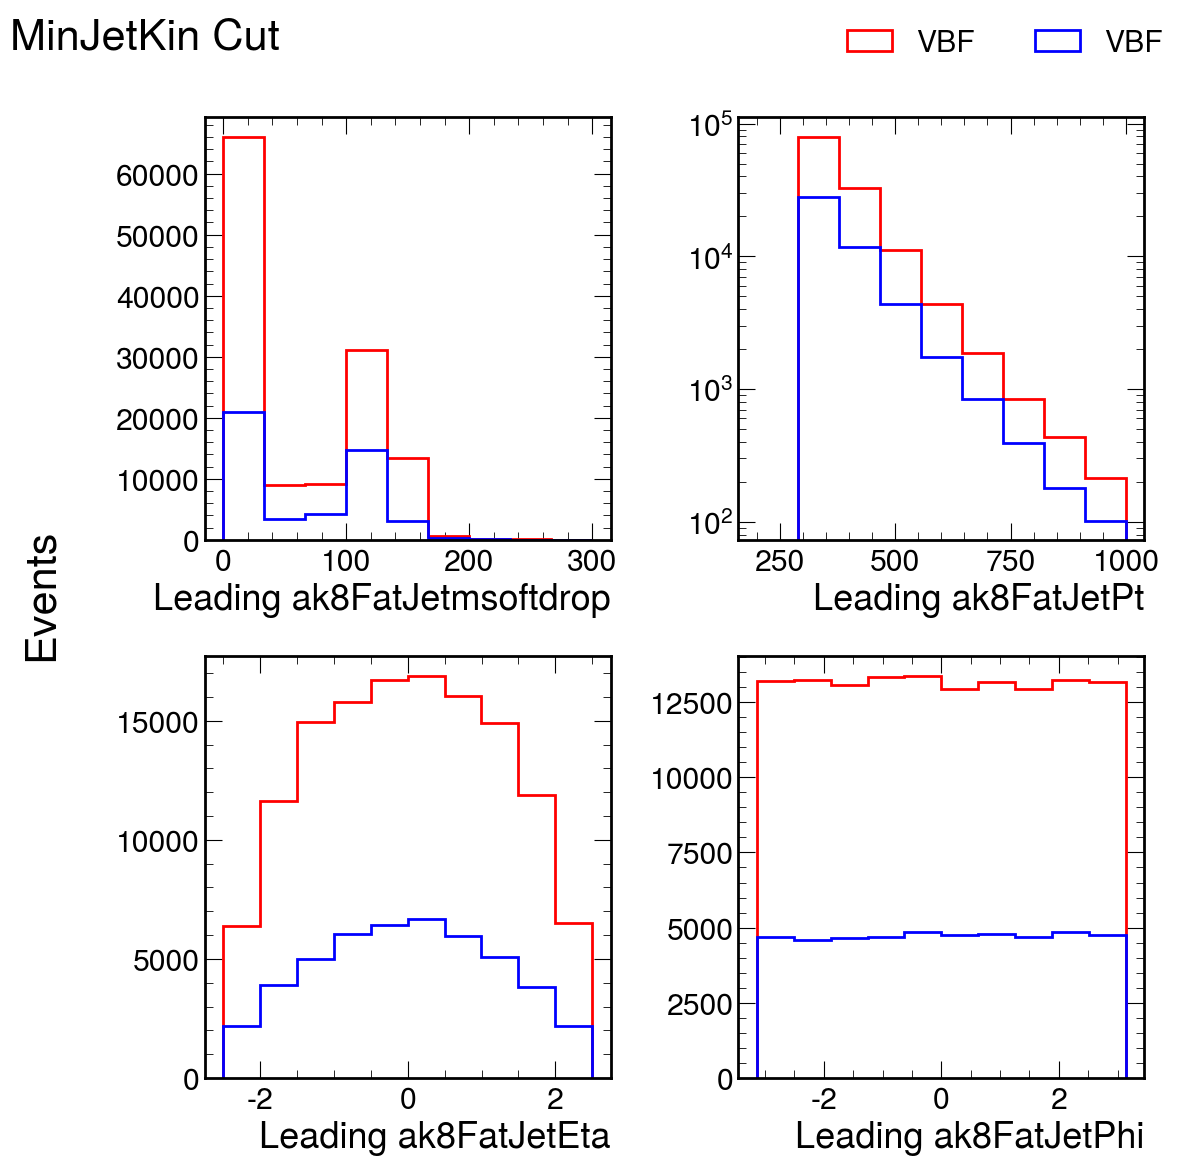

In [13]:
procs = [
        # 'ggF', 'VBF', 'VH', 
        'VBF', 'VBF'
        ]

fields = [
        # 'GenbPt', 'GenbEta', 'GenbPhi'
        'ak8FatJetmsoftdrop', 'ak8FatJetPt', 'ak8FatJetEta', 'ak8FatJetPhi'
        # 'ak8FatJetParTPXcc', 'ak8FatJetParTPXcc','ak8FatJetParTPXgg', 'ak8FatJetParTPXqq' 
    ]
scale = [None]*4
colors = ['red', 'blue', 'green', 'black']
cuts = [False,False]
jetN = [0,1]
# var = fill_hist(proc,field)[:,:2]

fig, ax = plt.subplots(2,2, figsize = (12,12))
plt.tight_layout(pad=2)

ax = ax.flat

# pt = ak.Array(fill_hist(proc,field))
for j, proc in enumerate(procs):
    cut = cuts[j]
    # pt = fill_hist(proc,'GenbPt')[:,:2]
    # pt = fill_hist(proc,'ak8FatJetPt')[:,:2]
    # high_pt = (np.arange(len(pt[:,0])), np.argmax(pt, axis = 1))
    # low_pt = (np.arange(len(pt[:,0])), np.argmin(pt, axis = 1))
    # mask = np.zeros(pt.shape) 
    # mask[high_pt] = True
    # print(mask)
    # print(high_pt)
    # print(proc)
    for i, field in enumerate(fields):
        # print(field)
        # field = fields[i]
        var = fill_hist(proc, field, cut=cut)[:,:2]
        var_stripped = var[:,jetN[j]][var[:,jetN[j]] > -999]
        print(len(var_stripped[:])/len(var[:, 0]))
        # if i == 0:
        # print(field, var[:5], var[high_pt][:5]) 
        if 'Pt' in field:
            bins = np.linspace(200,1000, 10)
            ax[i].hist(var[:,jetN[j]][var[:,jetN[j]] > -999], histtype='step', density=False, bins=bins, label = proc, color = colors[j], linewidth=2)
            ax[i].set(yscale = 'log', xlabel = 'Leading '+field)
        elif 'soft' in field:
            bins = np.linspace(0,300, 10)
            ax[i].hist(var[:,jetN[j]][var[:,jetN[j]] > -999], histtype='step', density=False, bins=bins, label = proc, color = colors[j], linewidth=2)
            ax[i].set(xlabel = 'Leading '+field)
        else:
            bins = None
            ax[i].hist(var[:,jetN[j]][var[:,jetN[j]] > -999], histtype='step', density=False, bins=bins, label = proc, color = colors[j], linewidth=2)
            ax[i].set(xlabel = 'Leading '+field)
            if scale[i]:
                ax[i].set(yscale=scale[i])

        del var

        # ax[1][i].hist(var[low_pt], histtype='step', density=True)
        # ax[1][i].set(xlabel = 'Sub-leading '+field)
    # del pt, var
nl = len(procs)
lines_labels = [a.get_legend_handles_labels() for a in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
lgd = fig.legend(lines[:nl], labels[:nl], 
                 # bbox_to_anchor=(1.05, 0.5),
                 loc='upper right',
                 ncol=3
                )
fig.supylabel('Events')
fig.suptitle('MinJetKin Cut', ha='left', x=0.01)

plt.tight_layout()
